# MiBiPreT example: Electron Balance with Amersfoort data

Diagnostic plots for data analysis on microbial biodegredation at the contaminant Amersfoort site. Author: Alraune Zech

Data based on the PhD thesis of *Johan van Leeuwen*, 2021 'Biodegredation of mono- and polyaromatic hydrocarbons in a contaminated aquifer originating from a former Pintsch gas factory site' which is equivalent to the manuscript of van Leeuwen et al., 2022 'Anaerobic degradation of benzene and other aromatic hydrocarbons in a tar-derived plume: Nitrate versus iron reducing conditions', J. of Cont. Hydrol. The data was provided by Johan van Leeuwen.
  
## Background: Amersfoort contaminant site

Close to the train station in Amersfoort, the Netherlands, the subsurface is contaminated with organic hydrocarbons forming a NAPL. Contamination originates from decades of operating manufactured gas plant, which dumped tar by-products in waste lagoons. The tar is a DNAPL and has spread into the underlying shallow unconfined aquifer. Sample wells were installed to measure various characteristics of the subsurface. The raw data contains measurements on
* environmental conditions, such as pH, redox potential, concentrations of oxygen, nitrate, etc
* contaminant concentration such as BTEX, indene, indane, naphtalene and multiple other (typically cyclic) petroleum hydrocarbons
* metabolite concentration, i.e. byproducts of degredation processes of contaminant
* isotope measurments for specific contaminants and samples
* counts of genes (RNA/DNA) of mibrobiota that is know to perform biodegredation as well as functional enzymes know to be responsible for biodegredation

In [1]:
import mibiscreen as mbs

/home/alraune/GitHub/MiBiPreT/mibiscreen/mibiscreen/analysis/reduction/transformation.py:14: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  pd.set_option('mode.use_inf_as_na', True)


## Data loading

In [2]:
file_path = './amersfoort.xlsx'

In [3]:
contaminants_raw,_ = mbs.load_excel(file_path,
                                    sheet_name = 'contaminants')
contaminants,units = mbs.standardize(contaminants_raw)

 Running function 'standardize()' on data
 Function performing check of data including:
  * check of column names and standardizing them.
  * check of units and outlining which to adapt.
  * check of values, replacing empty values by nan 
    and making them numeric
 Running function 'check_columns()' on data
29 quantities identified in provided data.
List of names with standard names:
----------------------------------
sample_name  -->  sample_nr
well  -->  obs_well
depth  -->  depth
aquifer  -->  aquifer
benzene  -->  benzene
toluene  -->  toluene
ethylbenzene  -->  ethylbenzene
pm-xylene  -->  pm_xylene
styrene  -->  styrene
o-xylene  -->  o_xylene
iso-propylbenzene  -->  isopropylbenzene
n-propylbenzene  -->  n_propylbenzene
3-ethyltoluene  -->  3_ethyltoluene
4-ethyltoluene  -->  4_ethyltoluene
1,3,5-trimethylbenzene  -->  135_trimethylbenzene
2-ethyltoluene  -->  2_ethyltoluene
1,2,4-trimethylbenzene  -->  124_trimethylbenzene
4-isopropyltouene  -->  4_isopropyltouene
1,2,3-trime

In [4]:
environment_raw,_ = mbs.load_excel(file_path,
                                   sheet_name = 'environment')
environment,units = mbs.standardize(environment_raw)

 Running function 'standardize()' on data
 Function performing check of data including:
  * check of column names and standardizing them.
  * check of units and outlining which to adapt.
  * check of values, replacing empty values by nan 
    and making them numeric
 Running function 'check_columns()' on data
24 quantities identified in provided data.
List of names with standard names:
----------------------------------
sample_name  -->  sample_nr
well  -->  obs_well
depth  -->  depth
aquifer  -->  aquifer
pH  -->  pH
EC  -->  EC
Redox  -->  redoxpot
DOC  -->  DOC
chloride  -->  chloride
oxygen  -->  oxygen
nitrate  -->  nitrate
nitrite  -->  nitrite
sulfate  -->  sulfate
sulfide  -->  sulfide
Mn2  -->  manganese2
Fe2  -->  iron2
Na  -->  sodium
Mg  -->  magnesium
K  -->  potassium
Ca  -->  calcium
phosphate  -->  phosphate
acetate  -->  acetate
fluoride  -->  fluoride
bromide  -->  bromide
----------------------------------
Identified column names have been standardized
______________

## Electron balance: Simple NA screening analysis

In [5]:
mbs.reductors(environment,
              include = True,
              ea_group = 'ONS')

1     12.789841
2      2.596891
3      1.669628
4     15.327849
5      1.069199
6      0.166493
7      6.497425
8      2.928226
9     11.929774
10    10.956322
11     8.762786
12     5.930307
13     5.174298
14     2.661290
15     2.177419
16     3.233611
17     5.428226
18     9.453187
19     0.178993
20     0.012500
21     0.012500
22     0.095747
23     0.178993
24     0.108247
25     0.108247
26     0.501574
27     4.950065
28    14.541129
29     6.799194
30    15.347581
31     6.507830
32     3.282661
33    17.951639
Name: total_reductors, dtype: float64

In [6]:
mbs.oxidators(contaminants,include = True,
              contaminant_group='BTEX')
mbs.oxidators(contaminants,include = True,
              contaminant_group='BTEXIIN')

Maybe data not in standardized format. Run 'standardize()' first.
_________________________________________________________________


1      0.003532
2      4.593173
3      1.330056
4      1.519835
5     23.970065
6     44.082629
7     19.740769
8     20.404649
9      0.767852
10     0.230424
11     0.003532
12     0.006973
13    28.781054
14    18.420932
15    14.621742
16     8.211821
17     2.709059
18     3.604108
19     6.596482
20    10.111647
21     9.638039
22     3.379366
23     0.692402
24     0.395568
25     0.038864
26     0.031641
27     0.010302
28     5.430876
29     3.708611
30     0.003532
31     0.003532
32     0.003532
33     0.005074
Name: total_oxidators_BTEXIIN, dtype: float64

In [7]:
data_NA = mbs.merge_data([environment,contaminants])
mbs.electron_balance(data_NA,include = True)

Maybe data not in standardized format. Run 'standardize()' first.
_________________________________________________________________


0     2481.262794
1      929.515473
2      480.489287
3        2.677492
4        1.833353
5     4345.807388
6     3538.259747
7     1842.751507
8     3621.560176
9       15.536562
10      47.548481
11       0.179781
12       0.144471
13       0.148917
14       0.329137
15     850.478973
16       0.044606
17       0.393775
18       2.003731
19       2.622892
20      10.085204
21       0.003777
22       1.255306
23       0.143508
24       0.565381
25       0.027135
26       0.001236
27       0.001297
28       0.028333
29       0.258511
30       0.273649
31       2.785262
32      15.852007
Name: e_balance, dtype: float64

In [8]:
na_traffic = mbs.sample_NA_traffic(data_NA,include = True)

### Electron balance as bar plot

Preprocess data selecting all relevant quantities and save in dictionary (`electron_balance_bar_data_prep()`) as input for visualization rountine `electron_balance_bar()`. Applied here to all samples for electron acceptors *oxygen*, *nitrate*, and *sulfate* and electron reducing contaminant groups *BTEXIIN* and *BTEX*. Samples are sorted according to available electrons.  

In [9]:
#data_NA.total_reductors.iloc[[21,11,20,3,17,18]]
#data_NA.total_oxidators_BTEX.iloc[[21,11,20,3,17,18]]
data_NA.total_oxidators_BTEXIIN.iloc[[21,11,20,3,17,18]]
data_NA.e_balance.iloc[[21,11,20,3,17,18]]


21     0.003777
11     0.179781
20    10.085204
3      2.677492
17     0.393775
18     2.003731
Name: e_balance, dtype: float64

{'EA capacity': {'height': array([8.76278616e+00, 3.28266129e+00, 4.95006504e+00, 1.45411290e+01,
       6.79919355e+00, 1.53475806e+01, 1.79516389e+01, 6.50783039e+00,
       1.27898413e+01, 1.19297737e+01, 1.09563215e+01, 5.17429761e+00,
       2.66129032e+00, 2.17741935e+00, 6.49742456e+00, 5.93030697e+00,
       1.06919875e+00, 3.23361082e+00, 5.42822581e+00, 9.45318678e+00,
       1.53278486e+01, 1.66493236e-01, 1.66962799e+00, 2.92822581e+00,
       2.59689126e+00, 1.78993236e-01, 1.25000000e-02, 1.25000000e-02,
       9.57466181e-02, 1.78993236e-01, 1.08246618e-01, 1.08246618e-01,
       5.01573881e-01]), 'color': 'C1', 'sample_nr': 0       1024(16)
1       1033(22)
2        241(16)
3        241(21)
4        241(30)
5        241(36)
6        320(21)
7        323(21)
8         323(9)
9         352(9)
10      4016(16)
11      4031(17)
12      4031(21)
13      4031(30)
14    A003(10.8)
15      A003(21)
16      A005(12)
17      A005(22)
18      A005(31)
19      A005(39)
20     A005(

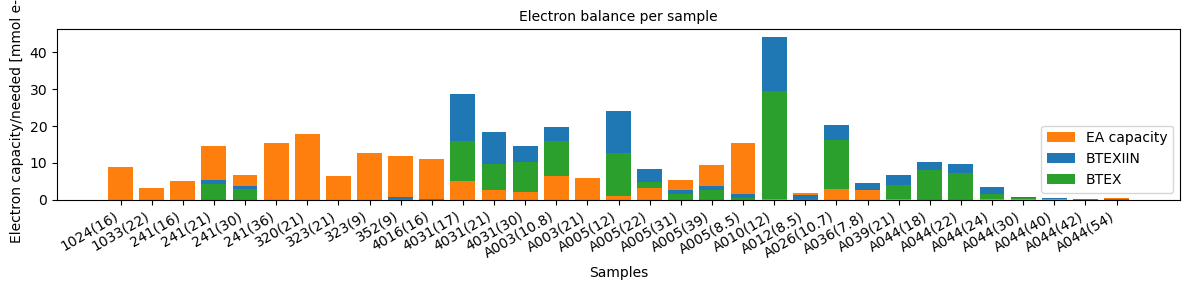

In [10]:
electron_balance_bar_dict = mbs.electron_balance_bar_data_prep(data_NA)
mbs.electron_balance_bar(electron_balance_bar_dict,
                         sample_nr = True,    
                         figsize = [12,3],
                         xtick_autorotate = True,
                         )

print(electron_balance_bar_dict)

#### Electron balance analysis for selected samples

Preprocess data selecting quantities for specified sample selection, save in dictionary and visualize.

(<Figure size 375x280 with 1 Axes>,
 <Axes: title={'center': 'Electron balance per sample'}, xlabel='Samples', ylabel='Electron capacity/needed [mmol e-/l]'>)

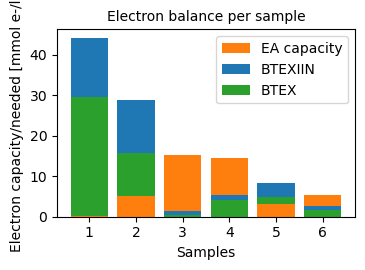

In [11]:
electron_balance_bar_dict = mbs.electron_balance_bar_data_prep(data_NA,
                                                               list_samples = [21,11,20,3,17,18])
mbs.electron_balance_bar(electron_balance_bar_dict,
                        loc = 'upper right')